# RNN, LSTM, and GRU for Sequential Data

**Unit:** Unit 4: Neural Networks Fundamentals

Every network we have trained so far looks at one *snapshot* — an image, a row of features — and forgets it immediately. But many real signals are *sequences* where order carries the meaning: sensor readings, stock prices, words in a sentence. To predict what comes next, a network needs **memory** of what came before. Recurrent networks add exactly that: a hidden state passed from one time step to the next. In `02_cnn_rnn_architectures.ipynb` we only printed these architectures' summaries; here we actually train the three classic recurrent cells — SimpleRNN, LSTM, and GRU — on the *same* forecasting task with the *same* hidden size and training budget, and let the measured validation error tell us which memory design works best on this task. The task uses a **real** signal: the hour-by-hour count of 911 emergency calls in Montgomery County, Pennsylvania.

## 📚 Learning Objectives

By completing this notebook, you will:
- Turn a continuous signal into (window -> next value) training sequences
- Explain intuitively what gates add: SimpleRNN vs. LSTM vs. GRU
- Train all three cells under an identical budget and compare validation MSE from actual results
- Read a predictions-vs-truth plot to judge forecast quality beyond a single number

## 🔗 Where this fits

**Builds on:** Unit 4, lesson 02 "Deep Learning Architectures: CNNs and RNNs" — the RNN described there is trained here against LSTM and GRU; all three learn by the Unit 3, lesson 04 recipe: define a loss, then use gradient descent to nudge the parameters.

**Used later in:** Course 08 (AIAT 122) — Unit 3 and Course 07 (AIAT 121) — Unit 4, where the same cells are used for language.

---


## 🎯 The day Google Translate changed engines

In **September 2016** Google replaced the statistical phrase-based system behind
Google Translate with **GNMT**: eight LSTM encoder layers and eight LSTM decoder
layers with attention. Google reported the new system reduced translation errors
by **55-85%** on several major language pairs, judged by bilingual human raters,
and it went to production first on Chinese→English. The recurrent cell in that
stack is the same `LSTM` you are about to train below — with more layers, far more
data, and a great deal more compute.

The sequel is just as instructive. A year later the transformer arrived, and
within a few years it had displaced recurrent stacks for most language work
because it can process a whole sequence in parallel instead of one timestep at a
time. **Gates were the answer to "how does memory survive many steps"; parallelism
was the answer to "how do we train on enough data".** Both answers are still
correct about the problem each solved.

### What goes wrong without memory

Every model so far in this course sees one snapshot and forgets it. Ask such a
model how many 911 calls to expect at 19:00 and the best it can do is the average
for 19:00 — it cannot know that the last six hours were unusually busy, that
yesterday was a public holiday, or that a storm started at 15:00. The forecast in
this notebook needs the *shape of the recent past*, and a hidden state carried
from one timestep to the next is the cheapest way to have it.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- A real hourly time series built from `montgomery_911_calls.csv` (already in this repo — no downloads)
- Sliding windows of **40 past hours** used to predict the **call volume in the next hour**

**Outputs:** What you'll see when you run the cells

- Printed dataset sizes and per-model parameter counts
- A table of final validation MSE for SimpleRNN, LSTM, and GRU
- One plot overlaying the three models' predictions against the true signal

---

Real series: 2000 consecutive hours, 2015-12-10 14:00 -> 2016-03-02 21:00
Calls per hour: min 0, mean 16.6, max 107
Correlation with the same hour yesterday (lag 24): 0.537  <- a real daily rhythm

Training windows:  1568  (each is 40 hours -> predict hour 41)
Validation windows:  392  (the held-out later weeks)


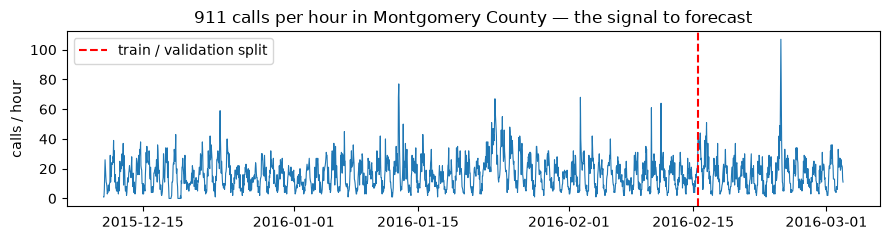

In [1]:
# Setup a forecasting task on a REAL signal: how many 911 emergency calls arrive in
# Montgomery County each hour. We cut it into sliding windows of 40 past hours -> predict
# hour 41. Note the TIME-ORDERED split: we validate on the future, never on shuffled rows.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

tf.get_logger().setLevel("ERROR")  # hide harmless tf.function retracing notices
keras.utils.set_random_seed(42)  # reproducible runs

# Read ONE column from the 123 MB call log — that is all a volume forecast needs.
calls = pd.read_csv("../../../Course 04/datasets/raw/montgomery_911_calls.csv",
                    usecols=["timeStamp"], nrows=400_000)
stamps = pd.to_datetime(calls["timeStamp"], errors="coerce").dropna().sort_values()

# Count the calls that arrived in each clock hour, then fill any missing hour with 0
# so the series sits on a complete, evenly spaced hourly grid (recurrent nets assume that).
hourly = stamps.dt.floor("h").value_counts().sort_index().asfreq("h", fill_value=0)

HOURS = 2000                      # about 83 consecutive days — classroom-sized
hourly = hourly.iloc[:HOURS]
raw_series = hourly.to_numpy(dtype="float64")
timeline = hourly.index

print(f"Real series: {len(raw_series)} consecutive hours, "
      f"{timeline[0]:%Y-%m-%d %H:%M} -> {timeline[-1]:%Y-%m-%d %H:%M}")
print(f"Calls per hour: min {raw_series.min():.0f}, mean {raw_series.mean():.1f}, "
      f"max {raw_series.max():.0f}")
print(f"Correlation with the same hour yesterday (lag 24): "
      f"{np.corrcoef(raw_series[:-24], raw_series[24:])[0, 1]:.3f}  <- a real daily rhythm")

# Sliding windows: 40 past hours -> predict the next hour
WINDOW = 40

# Time-ordered split: train on the first 80% of windows, validate on the last 20%.
n_windows = len(raw_series) - WINDOW
n_train = int(0.8 * n_windows)

# Standardize using ONLY the training portion. WHY: the validation hours are the
# "future" — using their mean/std would leak information we would not have in production.
split_point = n_train + WINDOW
mu, sigma = raw_series[:split_point].mean(), raw_series[:split_point].std()
series = (raw_series - mu) / sigma

X = np.array([series[i : i + WINDOW] for i in range(n_windows)])[..., None].astype("float32")
y = np.array([series[i + WINDOW] for i in range(n_windows)]).astype("float32")

X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train:], y[n_train:]

print(f"\nTraining windows:  {len(X_train)}  (each is {WINDOW} hours -> predict hour {WINDOW + 1})")
print(f"Validation windows:{len(X_val):5d}  (the held-out later weeks)")

plt.figure(figsize=(9, 2.5))
plt.plot(timeline, raw_series, lw=0.8)
plt.axvline(timeline[split_point], color="red", ls="--", label="train / validation split")
plt.title("911 calls per hour in Montgomery County — the signal to forecast")
plt.ylabel("calls / hour")
plt.legend()
plt.tight_layout()
plt.show()

## Three ways to remember: SimpleRNN, LSTM, GRU

All three cells read the window one step at a time, carrying a hidden state forward. They differ in *how* that memory is managed:

- **SimpleRNN** — one memory vector, **overwritten at every step** (`new state = f(input, old
  state)`). There is no mechanism to protect old information, so what happened 40 steps ago has
  been rewritten 40 times and mostly fades away (the *vanishing gradient* problem from the
  lectures).
- **LSTM** — adds a separate *cell state* that flows through time like a conveyor belt, plus
  three **gates** (small learned valves outputting 0-1): the **forget gate** decides what to
  erase from the belt, the **input gate** decides what new information to write onto it, and the
  **output gate** decides how much of the belt to reveal at this step. Because information can
  ride the belt untouched, long-range patterns survive.
- **GRU** — the economy version of the LSTM: two gates instead of three (an **update gate**
  merging forget+input into one "keep old vs. take new" dial, and a **reset gate** controlling
  how much history feeds the new candidate). Fewer parameters, often similar quality.

**The experiment:** identical data, identical hidden size (32 units), identical epochs, optimizer, and batch size — the *only* change is the recurrent cell. Note honestly: same hidden width does **not** mean same parameter count, because the gates are extra weights; the printed counts below show it.

One thing real data adds: the series is **standardized**, so an MSE of 1.0 would mean "no better than always predicting the average hour". Anything well below 1.0 is real forecasting skill.

In [2]:
# The fair comparison: SimpleRNN vs LSTM vs GRU in the SAME architecture, same data,
# same epochs — so the recurrent cell type is the only variable.
def build_model(cell_class):
    """Same architecture for all three: one recurrent layer (32 units) + linear output."""
    model = keras.Sequential(
        [keras.Input(shape=(WINDOW, 1)), cell_class(32), keras.layers.Dense(1)]
    )
    model.compile(optimizer="adam", loss="mse")
    return model

cells_to_test = [
    ("SimpleRNN", keras.layers.SimpleRNN),
    ("LSTM", keras.layers.LSTM),
    ("GRU", keras.layers.GRU),
]

EPOCHS = 15
results = {}
for name, cell_class in cells_to_test:
    keras.utils.set_random_seed(42)  # identical init/shuffling conditions for each model
    model = build_model(cell_class)
    hist = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=EPOCHS, batch_size=32, verbose=0)
    val_mse = model.evaluate(X_val, y_val, verbose=0)
    # keep the per-epoch history too: the learning curves are plotted further down
    results[name] = {"model": model, "params": model.count_params(),
                     "val_mse": val_mse, "history": hist.history}
    print(f"{name:9s} trained: {model.count_params():5,} parameters, "
          f"final val MSE = {val_mse:.4f}  ({EPOCHS} epochs)")

SimpleRNN trained: 1,121 parameters, final val MSE = 0.5224  (15 epochs)


LSTM      trained: 4,385 parameters, final val MSE = 0.5187  (15 epochs)


GRU       trained: 3,393 parameters, final val MSE = 0.5128  (15 epochs)


=== Final validation MSE, standardized units (same data, 32 units, 15 epochs each) ===
model        params   val MSE
GRU           3,393    0.5128
LSTM          4,385    0.5187
SimpleRNN     1,121    0.5224

Best on this run: GRU (val MSE 0.5128)

Baseline 'always predict the training average': val MSE 1.2382
Baseline 'repeat the previous hour'            : val MSE 0.6673
All three recurrent cells beat both baselines — the daily rhythm really is learnable.


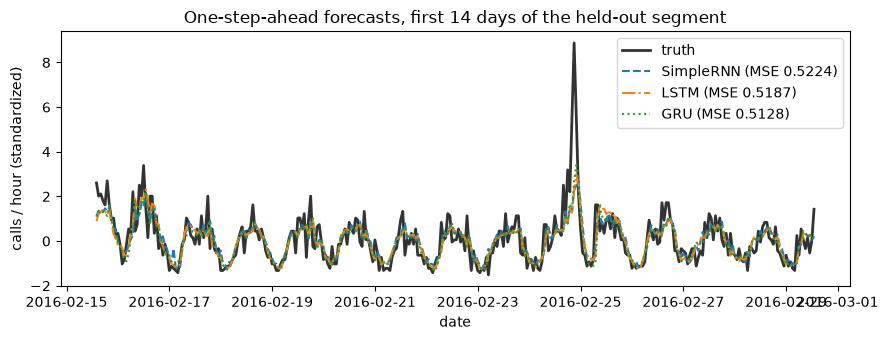

In [3]:
# Results: rank the three cells by validation MSE, then overlay their forecasts on
# the true held-out signal to see the errors, not just read them.
# One table of final validation MSE, ranked best (lowest) first
print("=== Final validation MSE, standardized units (same data, 32 units, 15 epochs each) ===")
print(f"{'model':<10} {'params':>8} {'val MSE':>9}")
ranked = sorted(results.items(), key=lambda kv: kv[1]["val_mse"])
for name, r in ranked:
    print(f"{name:<10} {r['params']:>8,} {r['val_mse']:>9.4f}")
print(f"\nBest on this run: {ranked[0][0]} (val MSE {ranked[0][1]['val_mse']:.4f})")

# Two baselines every forecaster must beat before anyone is allowed to be impressed.
# WHY: on real data a good-looking MSE means nothing until you know what "doing nothing" scores.
mse_mean = float(np.mean((y_val - 0.0) ** 2))              # always predict the training average
mse_persist = float(np.mean((y_val - X_val[:, -1, 0]) ** 2))  # repeat the previous hour
print(f"\nBaseline 'always predict the training average': val MSE {mse_mean:.4f}")
print(f"Baseline 'repeat the previous hour'            : val MSE {mse_persist:.4f}")
print(f"All three recurrent cells beat both baselines — the daily rhythm really is learnable.")

# One plot: the three models' one-step-ahead predictions vs. the true signal
# Predict the whole validation segment with each model for the overlay plot.
preds = {name: r["model"].predict(X_val, verbose=0).ravel() for name, r in results.items()}
t_val = timeline[n_train + WINDOW :]

# Show the first two weeks of the validation segment: the whole span would be an unreadable smear.
show = 24 * 14
plt.figure(figsize=(9, 3.5))
plt.plot(t_val[:show], y_val[:show], "k-", lw=2, label="truth", alpha=0.8)
for (name, p), style in zip(preds.items(), ["--", "-.", ":"]):
    plt.plot(t_val[:show], p[:show], style, lw=1.5,
             label=f"{name} (MSE {results[name]['val_mse']:.4f})")
plt.title("One-step-ahead forecasts, first 14 days of the held-out segment")
plt.xlabel("date")
plt.ylabel("calls / hour (standardized)")
plt.legend()
plt.tight_layout()
plt.show()

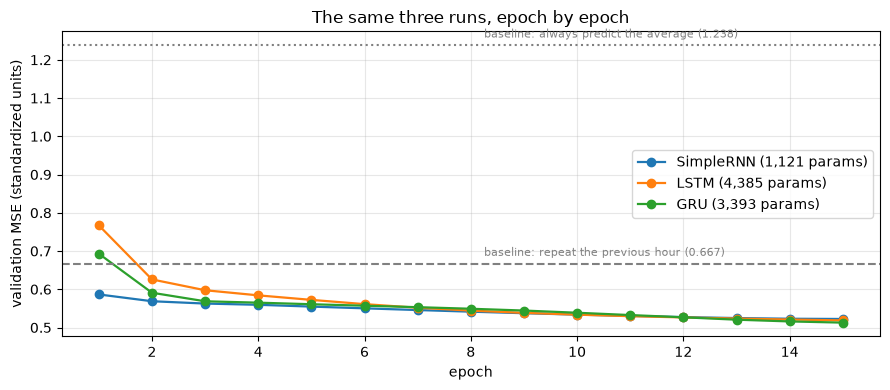

Epoch 1, before any of them knows anything: SimpleRNN 0.587, LSTM 0.767, GRU 0.693
Epoch 15, the numbers in the table above: SimpleRNN 0.522, LSTM 0.519, GRU 0.513

Gap between the best and worst cell at the final epoch : 0.0095
Largest single-epoch move by any curve in the last 5 epochs: 0.0063
Those two are the same order of magnitude (1.5x apart).
A ranking that stopping one epoch earlier could reorder is a snapshot, not a finding.


In [4]:
# WHAT/WHY: the table gives each cell ONE number at the end of training. The histories
# recorded during the same runs show the whole descent — and whether a 1% gap between
# three curves is a ranking or a coincidence. No retraining: this is the same 15 epochs.
fig, ax = plt.subplots(figsize=(9, 4.0))
for (name, r), color in zip(results.items(), ["tab:blue", "tab:orange", "tab:green"]):
    ax.plot(range(1, EPOCHS + 1), r["history"]["val_loss"], "o-", color=color, lw=1.6,
            label=f"{name} ({r['params']:,} params)")
ax.axhline(mse_persist, ls="--", color="gray")
ax.text(EPOCHS * 0.55, mse_persist + 0.02, "baseline: repeat the previous hour "
        f"({mse_persist:.3f})", fontsize=8, color="gray")
ax.axhline(mse_mean, ls=":", color="gray")
ax.text(EPOCHS * 0.55, mse_mean + 0.02, "baseline: always predict the average "
        f"({mse_mean:.3f})", fontsize=8, color="gray")
ax.set_xlabel("epoch"); ax.set_ylabel("validation MSE (standardized units)")
ax.set_title("The same three runs, epoch by epoch")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

final_spread = (max(r["history"]["val_loss"][-1] for r in results.values())
                - min(r["history"]["val_loss"][-1] for r in results.values()))
wobble = max(abs(r["history"]["val_loss"][e] - r["history"]["val_loss"][e - 1])
             for r in results.values() for e in range(EPOCHS - 5, EPOCHS))
print(f"Epoch 1, before any of them knows anything: "
      + ", ".join(f"{n} {r['history']['val_loss'][0]:.3f}" for n, r in results.items()))
print(f"Epoch {EPOCHS}, the numbers in the table above: "
      + ", ".join(f"{n} {r['history']['val_loss'][-1]:.3f}" for n, r in results.items()))
print(f"\nGap between the best and worst cell at the final epoch : {final_spread:.4f}")
print(f"Largest single-epoch move by any curve in the last 5 epochs: {wobble:.4f}")
print(f"Those two are the same order of magnitude ({final_spread / wobble:.1f}x apart).")
print("A ranking that stopping one epoch earlier could reorder is a snapshot, not a finding.")


### 👀 Read the learning curves

**The first epoch already says something the final table cannot.** The gate-free
SimpleRNN is *ahead* of both gated cells at epoch 1 (0.587, against LSTM 0.767 and GRU
0.693) — it has a quarter of the LSTM's parameters, so it has less to move before it is
doing something useful. The gated cells catch up by about epoch 5, and from there the
three curves lie on top of each other.

**The distance worth reporting is vertical, to the grey dashed line.** "Repeat the previous
hour" scores 0.667 and "always predict the average" scores 1.238; all three cells finish
near 0.52. That drop is the skill the network added, and it is about 15 times larger than
anything separating the three cells from each other.

**The distance students are tempted to lead with is the gap between the coloured curves.**
At the final epoch it is **0.0095** — while a single curve still moves by up to **0.0063**
from one epoch to the next this late in training. The two quantities are the same size
(1.5× apart). Stop one epoch earlier and the podium can reshuffle, which is why the
notebook refuses to crown a winner.

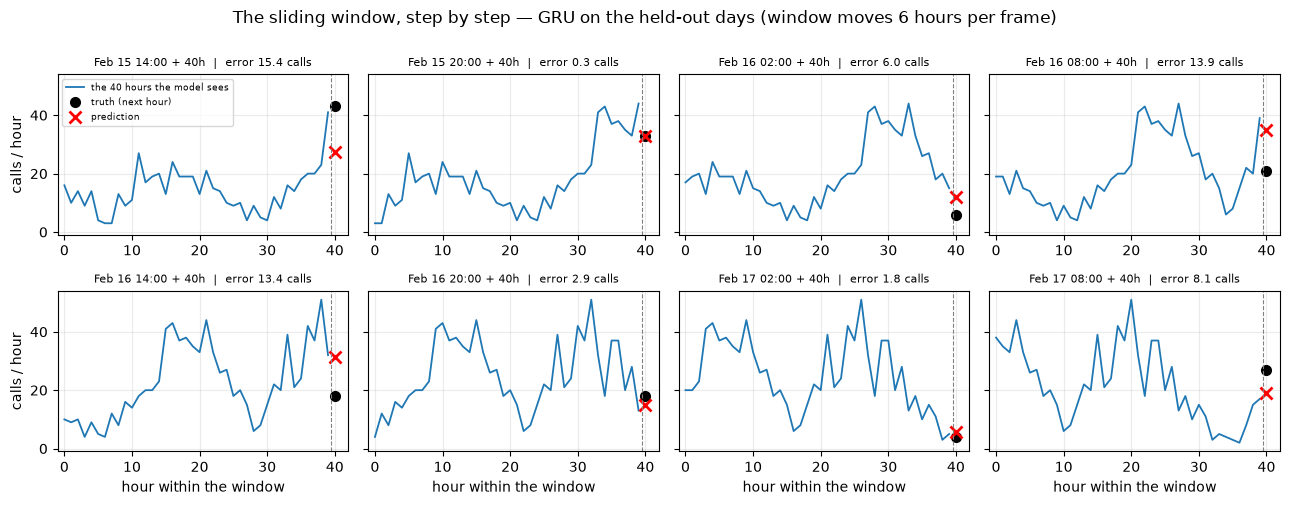

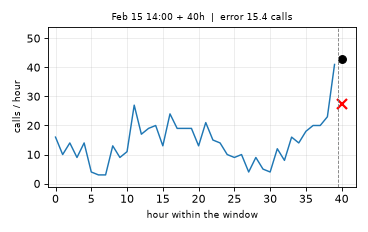

Animation above: 8 frames, the window sliding 6 hours each time.

frame | window starts | last hour seen |  truth | predicted |  error
----------------------------------------------------------------------
    1 | Feb 15 14:00 |           41.0 |   43.0 |      27.6 |   15.4
    2 | Feb 15 20:00 |           44.0 |   33.0 |      32.7 |    0.3
    3 | Feb 16 02:00 |           15.0 |    6.0 |      12.0 |    6.0
    4 | Feb 16 08:00 |           39.0 |   21.0 |      34.9 |   13.9
    5 | Feb 16 14:00 |           32.0 |   18.0 |      31.4 |   13.4
    6 | Feb 16 20:00 |           13.0 |   18.0 |      15.1 |    2.9
    7 | Feb 17 02:00 |            5.0 |    4.0 |       5.8 |    1.8
    8 | Feb 17 08:00 |           17.0 |   27.0 |      18.9 |    8.1

Mean error over these eight predictions: 7.7 calls/hour (worst 15.4, best 0.3), against a held-out signal that ranges 1 to 107 calls/hour.


In [5]:
# WHAT/WHY: "40 past hours -> the next hour" is a sentence; this is the picture. We walk
# the input window forward through the held-out days, one frame per position: the blue
# line is what the model is allowed to see, the black dot is the truth it must hit, the
# red cross is what it predicted. Storyboard first (always renders), then the same frames
# as a GIF. Idiom borrowed from Course 09's course09_step_viz (frames_to_gif_bytes /
# display_gif), inlined so this notebook stands alone. Nothing is retrained.
import io
from PIL import Image
from IPython.display import Image as IPyImage, display

best_name = min(results, key=lambda k: results[k]["val_mse"])
best_pred = preds[best_name]

STEP, N_FRAMES = 6, 8                     # every 6 hours, 8 positions = ~2 days
starts = [i * STEP for i in range(N_FRAMES)]

def raw(v):                               # undo the standardization, for readable axes
    return v * sigma + mu

lo = min(raw(X_val[s, :, 0]).min() for s in starts) - 3
hi = max(raw(X_val[s, :, 0]).max() for s in starts) + 3

def draw_window(ax, s):
    hours = np.arange(WINDOW)
    ax.plot(hours, raw(X_val[s, :, 0]), color="tab:blue", lw=1.3,
            label="the 40 hours the model sees")
    ax.plot([WINDOW], [raw(y_val[s])], "ko", ms=7, label="truth (next hour)")
    ax.plot([WINDOW], [raw(best_pred[s])], "rx", ms=9, mew=2, label="prediction")
    ax.axvline(WINDOW - 0.5, color="gray", lw=0.8, ls="--")
    ax.set_ylim(lo, hi); ax.set_xlim(-1, WINDOW + 2)
    err = abs(raw(best_pred[s]) - raw(y_val[s]))
    ax.set_title(f"{t_val[s]:%b %d %H:%M} + 40h  |  error {err:.1f} calls", fontsize=8)

# --- storyboard: all eight positions at once ---
fig, axes = plt.subplots(2, 4, figsize=(13, 5.0), sharey=True)
for ax, s in zip(axes.ravel(), starts):
    draw_window(ax, s)
    ax.grid(alpha=0.25)
axes[0, 0].legend(fontsize=6.5, loc="upper left")
for ax in axes[1]:
    ax.set_xlabel("hour within the window")
for ax in axes[:, 0]:
    ax.set_ylabel("calls / hour")
fig.suptitle(f"The sliding window, step by step — {best_name} on the held-out days "
             f"(window moves {STEP} hours per frame)", y=1.0)
plt.tight_layout()
plt.show()

# --- the same eight positions as an animation ---
def frames_to_gif_bytes(frames, duration_ms=900):
    """Encode uint8 RGB frames as one animated GIF (Course 09 step-viz idiom)."""
    imgs = [Image.fromarray(np.asarray(f, dtype=np.uint8)) for f in frames]
    buf = io.BytesIO()
    imgs[0].save(buf, format="GIF", save_all=True, append_images=imgs[1:],
                 duration=duration_ms, loop=0)
    return buf.getvalue()

def fig_to_rgb(fig):
    fig.canvas.draw()
    rgb = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
    plt.close(fig)
    return rgb

frames = []
for s in starts:
    f, ax = plt.subplots(figsize=(4.6, 2.9), dpi=80)
    draw_window(ax, s)
    ax.grid(alpha=0.25)
    ax.set_xlabel("hour within the window", fontsize=8)
    ax.set_ylabel("calls / hour", fontsize=8)
    f.tight_layout()
    frames.append(fig_to_rgb(f))
display(IPyImage(data=frames_to_gif_bytes(frames), format="gif"))

print(f"Animation above: {len(frames)} frames, the window sliding {STEP} hours each time.\n")
print(f"{'frame':>5} | {'window starts':>13} | {'last hour seen':>14} | {'truth':>6} | "
      f"{'predicted':>9} | {'error':>6}")
print("-" * 70)
errs = []
for fi, s_ in enumerate(starts, start=1):
    last, truth, pred = raw(X_val[s_, -1, 0]), raw(y_val[s_]), raw(best_pred[s_])
    errs.append(abs(pred - truth))
    print(f"{fi:>5} | {t_val[s_]:%b %d %H:%M} | {last:>14.1f} | {truth:>6.1f} | "
          f"{pred:>9.1f} | {abs(pred - truth):>6.1f}")
print(f"\nMean error over these eight predictions: {np.mean(errs):.1f} calls/hour "
      f"(worst {max(errs):.1f}, best {min(errs):.1f}), against a held-out signal that "
      f"ranges {raw(y_val).min():.0f} to {raw(y_val).max():.0f} calls/hour.")


### 👀 Read the storyboard

Each panel is **one prediction**. Everything left of the dashed line is the model's entire
knowledge of the world at that moment — 40 hourly call counts, no calendar, no weather, no
holiday flag — and it must place the red cross on the black dot. Then the window slides six
hours and it happens again.

**What the eight frames show, from the printed table.** The cross almost always lands near
the *last* hour the model saw, pulled a little toward the middle of the range: 41 → 27.6,
44 → 32.7, 39 → 34.9 when the window ends high, but 13 → 15.1 and 5 → 5.8 when it ends low.
The network has learned the shape of the daily cycle and one blunt statistical fact — an
unusually busy hour is usually followed by a calmer one, and a quiet hour by a busier one.
That damping is why it beats "repeat the previous hour" (0.667 → 0.513 MSE), and it is a
real, if modest, piece of knowledge about emergency calls.

**And where it fails.** Frame 1: the window ends on a climb at 41 calls, the model damps to
27.6 — and the surge actually continued to 43. Frames 4 and 5 are the mirror image: it
damped, but nowhere near enough (predicted 34.9 and 31.4, the truth was 21 and 18). Mean
error over the eight frames is **7.7 calls per hour**.

That residual is the honest subject of this lesson. A car crash at 09:00 is not written
anywhere in the previous forty hours, and no amount of gating will read it there.

### What the numbers say

**On this run the GRU won**, with a final validation MSE of **0.5128**, followed by the LSTM (**0.5187**) and the SimpleRNN (**0.5224**). Four honest readings of that table:

1. **All three genuinely forecast.** Predicting the training average every hour scores **1.2382**
   on the held-out weeks, and simply repeating the previous hour's count scores **0.6673**. Every
   recurrent cell beats both, so the daily rhythm of emergency calls really is learnable —
   the models are not just echoing the last value back at us.
2. **The margin between the three cells is tiny — about 1% — and that is expected here.** Everything
   the models need (yesterday evening's peak, last night's trough) fits inside the 40-hour input
   window. That is exactly the regime a gate-free SimpleRNN can still handle, which is why it stays
   within striking distance of the LSTM at a quarter of the parameters (**1,121 vs. 4,385**). Gates
   earn their cost on *longer* sequences with *long-range* dependencies — remembering something from
   hundreds of steps ago, as in text — where a SimpleRNN's constantly overwritten memory collapses.
3. **The residual error is real-world unpredictability, not a training failure.** Roughly half the
   hour-to-hour variance in 911 volume is genuinely unforecastable: a car crash or a house fire is
   not announced by the previous 40 hours. Compare that with a textbook sine wave, where the only
   thing standing between a model and MSE 0 is noise the author added on purpose. A model that
   drove this validation MSE to 0 would be a warning sign, not a triumph.
4. **Rankings this close are fragile.** With a different seed, a different 2,000-hour slice, or a
   different epoch budget the ordering can shuffle. The durable lesson is not "GRU is always best"
   — it is the *mechanism*: gated cells can protect information across many steps, while a
   SimpleRNN rewrites its entire memory at every step.

## 💬 Discuss

Argue from the table: GRU **0.5128** (3,393 params), LSTM **0.5187** (4,385),
SimpleRNN **0.5224** (1,121); baselines "predict the training average"
**1.2382** and "repeat the previous hour" **0.6673**.

1. The three cells are separated by about **1%**, while the gap to the
   "repeat the previous hour" baseline is about **23%**. **Which of those two
   comparisons belongs in your report, and which one would a student be tempted to
   lead with?** Say what the 1% would have to look like before you'd claim a winner.
2. The SimpleRNN has a **quarter** of the LSTM's parameters and lost by 0.0096.
   You are deploying to a device with tight memory. **Argue for the SimpleRNN.**
   Then argue against it using a property of the *task*, not of the numbers — what
   would have to change about the forecasting problem to make the gates pay?
3. This model is scored with MSE, which punishes over- and under-forecasting
   equally. You are staffing ambulance dispatchers for a Saudi city. **Is that
   symmetry acceptable?** Write the loss you would actually want, in words, and
   say who in the organisation should sign off on the asymmetry.
4. Roughly half the hour-to-hour variance here is genuinely unpredictable — a
   house fire is not announced by the previous 40 hours. **How would you explain
   an unbeatable error floor to a client who has been shown a textbook forecasting
   demo with a near-perfect fit?**


## ⚠️ Where this breaks

The four numbered readings above are the honest interpretation; here are the
conditions under which this whole setup stops working.

- **The 40-hour window is a hard horizon.** Anything older than 40 hours is
  invisible to the model by construction — weekly seasonality, public holidays,
  Ramadan timings, a heatwave that started three days ago. That is a property of
  the *data preparation*, not of the cell type, and no amount of LSTM will recover it.
- **A 1% margin between three models is not a ranking.** One seed, one 2,000-hour
  slice, one epoch budget. Change any of them and the order can shuffle — the
  notebook says so, and it is the single most-copied mistake in student projects.
- **Recurrent models cannot be parallelised across time.** Each step needs the
  previous state, so training time scales with sequence length in a way
  convolutions and transformers do not. On long sequences this is the reason to
  switch architecture, before accuracy even enters the argument.
- **Gates cost parameters and buy nothing when the dependency is short.** LSTM
  needed 4,385 parameters to the SimpleRNN's 1,121 and won by 0.0096, because
  everything the task needs (yesterday's peak, last night's trough) fits inside
  the window. **Cheaper alternative to check first:** a seasonal-naive baseline
  ("same hour last week") or a classical model such as SARIMA. Our simplest
  baseline — repeat the previous hour — already scored 0.6673, and a neural network
  that cannot beat a one-line baseline is not a result.
- **The split must respect time, and it does here.** Validating on the *later*
  weeks is what makes this honest; a shuffled split would let the model see the
  future around each validation point and would report a much better number for a
  much worse model. This is the most common way a forecasting project lies to itself.
- **Standardisation was fitted on the training portion.** If you refit the scaler
  on the whole series you leak future statistics into the past — a subtle version
  of the same failure.
- **An irreducible error floor is normal on real data.** MSE approaching 0 on a
  real emergency-call series would be evidence of leakage, not of skill.


## 📚 References

1. Elman, J. L. (1990). *Finding Structure in Time*. Cognitive Science, 14(2), 179–211.
2. Hochreiter, S., & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation, 9(8), 1735–1780.
3. Cho, K., van Merriënboer, B., Gulcehre, C., et al. (2014). *Learning Phrase Representations using RNN Encoder–Decoder for Statistical Machine Translation* (GRU). EMNLP. <https://arxiv.org/abs/1406.1078>
4. Gu, A., & Dao, T. (2023). *Mamba: Linear-Time Sequence Modeling with Selective State Spaces*. arXiv. <https://arxiv.org/abs/2312.00752>
5. Beck, M., Pöppel, K., Spanring, M., et al. (2024). *xLSTM: Extended Long Short-Term Memory*. arXiv. <https://arxiv.org/abs/2405.04517>
6. Ansari, A. F., Shchur, O., Küken, J., et al. (2025). *Chronos-2: From Univariate to Universal Forecasting*. arXiv. <https://arxiv.org/abs/2510.15821>